In [1]:
# Mount Google Drive folder as a local folder
# Note: This mounts your entire drive, not the current folder
from google.colab import drive
drive.mount('/mydrive')

Mounted at /mydrive


In [2]:
#TODO replace the path with your path in drive
#This usually takes 15-20 minutes to run
!cp -r /mydrive/MyDrive/Colab_Notebooks/CV/CV_project/dataset ./

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import os
import shutil

import tensorflow as tf
from tensorflow.keras.layers import Conv2D, MaxPool2D, Dense, Flatten, Dropout
from tensorflow.keras.models import Sequential, Model

In [4]:
# TRAIN_PATH = '../input/fruits-fresh-and-rotten-for-classification/dataset/train/'
# TEST_PATH = '../input/fruits-fresh-and-rotten-for-classification/dataset/test/'
TRAIN_PATH = '/mydrive/MyDrive/Colab_Notebooks/CV/CV_project/dataset/train/'
TEST_PATH = '/mydrive/MyDrive/Colab_Notebooks/CV/CV_project/dataset/test/'
SIZE = (224, 224)

In [5]:
labels = []
for class_ in os.listdir(TRAIN_PATH):
    labels.append(class_)
NUM_LABELS = len(labels)

print(labels)

['freshapples', 'freshbanana', 'freshoranges', 'rottenapples', 'rottenbanana', 'rottenoranges']


In [7]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen=ImageDataGenerator(rescale=1./255, validation_split = 0.1)
test_datagen = ImageDataGenerator(rescale=1./255)

'''
Comments:
- ImageDataGenerator will resize all images to target_size
- x_col is the column where the images' names are
- y_col is the column where the labels are
- has_ext means that the images' names include a file extension, e.g. image_name.jpg
- Here you can change the targe_size to resize all images to different shapes.
Maybe larger images help in getting a better accuracy
'''
train_dataset = datagen.flow_from_directory(batch_size=32,
                                                 directory=TRAIN_PATH,
                                                 shuffle=True,
                                                classes=labels,
                                                 target_size=SIZE,
                                                 subset="training",
                                                 class_mode='categorical')

val_dataset = datagen.flow_from_directory(batch_size=32,
                                                 directory=TEST_PATH ,
                                                 shuffle=True,
                                                classes=labels,
                                                 target_size=SIZE,
                                                 subset="validation",
                                                 class_mode='categorical')

Found 9813 images belonging to 6 classes.
Found 268 images belonging to 6 classes.


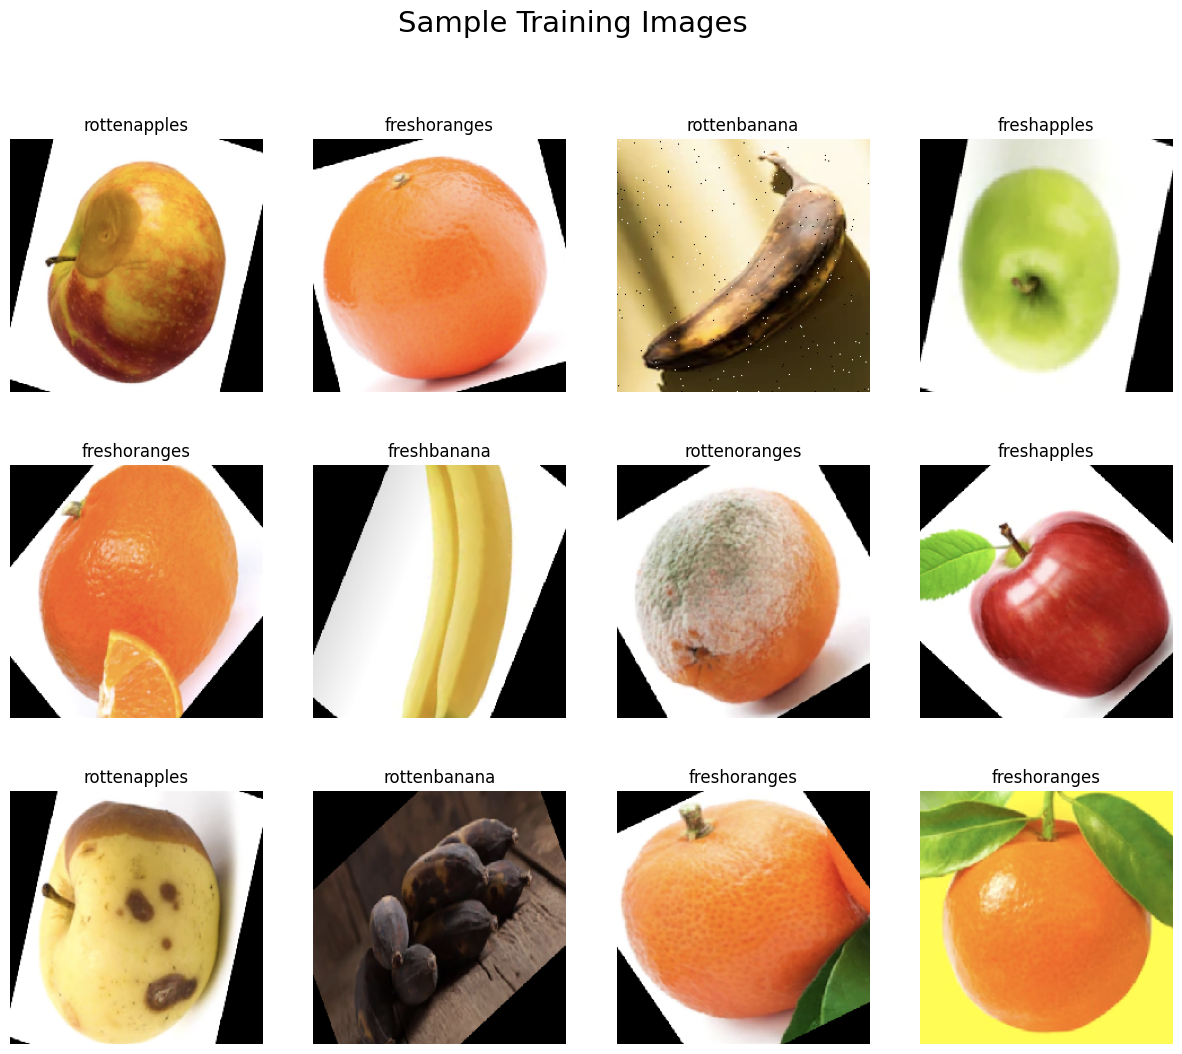

In [8]:
fig, ax = plt.subplots(nrows=3, ncols=4, figsize=(15, 12))
idx = 0

for i in range(3):
    for j in range(4):
        label = labels[np.argmax(train_dataset[0][1][idx])]
        ax[i, j].set_title(f"{label}")
        ax[i, j].imshow(train_dataset[0][0][idx][:, :, :])
        ax[i, j].axis("off")
        idx += 1

# plt.tight_layout()
plt.suptitle("Sample Training Images", fontsize=21)
plt.show()

In [11]:
from tensorflow.keras.applications import ResNet50

In [12]:
from keras.models import Model
from keras.layers import Input, Dense
from tensorflow.keras.optimizers import  Adam


In [14]:
model = ResNet50(
    include_top=True,
    weights=None,
    input_tensor=Input(shape=(224, 224, 3)),
    input_shape=None,
    pooling=None,
    classes=6,
)


In [15]:

from keras.callbacks import LearningRateScheduler

In [16]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report
import keras
from keras.layers import *
from keras.models import *
from keras.preprocessing import image
from keras.callbacks import EarlyStopping
from keras.callbacks import ModelCheckpoint

In [18]:
model.compile(loss='categorical_crossentropy',optimizer="adam",metrics=['accuracy'])
model.summary()
epochs = 30
stepsperepoch=187
validationsteps=1
annealer = LearningRateScheduler(lambda x: 1e-3 * 0.95 ** x)
es = EarlyStopping(monitor='val_acc', mode='max', verbose=1, patience=100)
mc = ModelCheckpoint("resnet50.h5", monitor='val_loss',save_best_only=True, mode='min',verbose=1)

Model: "resnet50"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 23,600,006 (90.03 MB)

 Trainable params: 23,546,886 (89.82 MB)

 Non-trainable params: 53,120 (207.50 KB)

In [19]:
hist = model.fit(
    train_dataset,
    epochs=epochs,
    callbacks=[annealer,mc,es],
    steps_per_epoch=stepsperepoch,
    validation_data= val_dataset,
    validation_steps = validationsteps
)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30


/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(None, 224, 224, 3))
  warnings.warn(msg)


187/187 ━━━━━━━━━━━━━━━━━━━━ 0s 314ms/step - accuracy: 0.6419 - loss: 1.5424
Epoch 1: val_loss improved from inf to 6.52910, saving model to resnet50.h5


187/187 ━━━━━━━━━━━━━━━━━━━━ 121s 345ms/step - accuracy: 0.6425 - loss: 1.5392 - val_accuracy: 0.1250 - val_loss: 6.5291 - learning_rate: 0.0010
Epoch 2/30
  3/187 ━━━━━━━━━━━━━━━━━━━━ 10s 59ms/step - accuracy: 0.8594 - loss: 0.3529

...

187/187 ━━━━━━━━━━━━━━━━━━━━ 37s 196ms/step - accuracy: 0.9105 - loss: 0.2513 - val_accuracy: 0.8750 - val_loss: 0.3555 - learning_rate: 7.3509e-04
Epoch 8/30
120/187 ━━━━━━━━━━━━━━━━━━━━ 13s 195ms/step - accuracy: 0.9370 - loss: 0.1751
Epoch 8: val_loss did not improve from 0.35550
187/187 ━━━━━━━━━━━━━━━━━━━━ 23s 126ms/step - accuracy: 0.9357 - loss: 0.1777 - val_accuracy: 0.8750 - val_loss: 0.3636 - learning_rate: 6.9834e-04
Epoch 9/30
187/187 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step - accuracy: 0.9218 - loss: 0.2320
Epoch 9: val_loss improved from 0.35550 to 0.18814, saving model to resnet50.h5


187/187 ━━━━━━━━━━━━━━━━━━━━ 37s 199ms/step - accuracy: 0.9218 - loss: 0.2320 - val_accuracy: 0.9062 - val_loss: 0.1881 - learning_rate: 6.6342e-04
Epoch 10/30
120/187 ━━━━━━━━━━━━━━━━━━━━ 13s 197ms/step - accuracy: 0.9193 - loss: 0.2189
Epoch 10: val_loss did not improve from 0.18814
187/187 ━━━━━━━━━━━━━━━━━━━━ 24s 128ms/step - accuracy: 0.9225 - loss: 0.2112 - val_accuracy: 0.8438 - val_loss: 0.4099 - learning_rate: 6.3025e-04
Epoch 11/30
187/187 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step - accuracy: 0.9465 - loss: 0.1511
Epoch 11: val_loss improved from 0.18814 to 0.18545, saving model to resnet50.h5


187/187 ━━━━━━━━━━━━━━━━━━━━ 38s 202ms/step - accuracy: 0.9465 - loss: 0.1512 - val_accuracy: 0.9062 - val_loss: 0.1854 - learning_rate: 5.9874e-04
Epoch 12/30
120/187 ━━━━━━━━━━━━━━━━━━━━ 13s 196ms/step - accuracy: 0.9509 - loss: 0.1400
Epoch 12: val_loss improved from 0.18545 to 0.00708, saving model to resnet50.h5


187/187 ━━━━━━━━━━━━━━━━━━━━ 25s 135ms/step - accuracy: 0.9508 - loss: 0.1395 - val_accuracy: 1.0000 - val_loss: 0.0071 - learning_rate: 5.6880e-04
Epoch 13/30
187/187 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step - accuracy: 0.9567 - loss: 0.1178
Epoch 13: val_loss did not improve from 0.00708
187/187 ━━━━━━━━━━━━━━━━━━━━ 37s 194ms/step - accuracy: 0.9567 - loss: 0.1178 - val_accuracy: 0.6250 - val_loss: 1.3329 - learning_rate: 5.4036e-04
Epoch 14/30
120/187 ━━━━━━━━━━━━━━━━━━━━ 12s 189ms/step - accuracy: 0.9551 - loss: 0.1270
Epoch 14: val_loss did not improve from 0.00708
187/187 ━━━━━━━━━━━━━━━━━━━━ 23s 123ms/step - accuracy: 0.9572 - loss: 0.1225 - val_accuracy: 0.8125 - val_loss: 0.5031 - learning_rate: 5.1334e-04
Epoch 15/30
187/187 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step - accuracy: 0.9645 - loss: 0.1027
Epoch 15: val_loss did not improve from 0.00708
187/187 ━━━━━━━━━━━━━━━━━━━━ 36s 192ms/step - accuracy: 0.9645 - loss: 0.1027 - val_accuracy: 0.9688 - val_loss: 0.1154 - learning_rate: 4.8767e

187/187 ━━━━━━━━━━━━━━━━━━━━ 25s 133ms/step - accuracy: 0.9888 - loss: 0.0329 - val_accuracy: 1.0000 - val_loss: 0.0052 - learning_rate: 2.7739e-04
Epoch 27/30
187/187 ━━━━━━━━━━━━━━━━━━━━ 0s 196ms/step - accuracy: 0.9922 - loss: 0.0245
Epoch 27: val_loss did not improve from 0.00517
187/187 ━━━━━━━━━━━━━━━━━━━━ 37s 197ms/step - accuracy: 0.9922 - loss: 0.0245 - val_accuracy: 0.9375 - val_loss: 0.0925 - learning_rate: 2.6352e-04
Epoch 28/30
120/187 ━━━━━━━━━━━━━━━━━━━━ 12s 191ms/step - accuracy: 0.9843 - loss: 0.0499
Epoch 28: val_loss did not improve from 0.00517
187/187 ━━━━━━━━━━━━━━━━━━━━ 23s 124ms/step - accuracy: 0.9854 - loss: 0.0458 - val_accuracy: 1.0000 - val_loss: 0.0448 - learning_rate: 2.5034e-04
Epoch 29/30
187/187 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step - accuracy: 0.9850 - loss: 0.0435
Epoch 29: val_loss did not improve from 0.00517
187/187 ━━━━━━━━━━━━━━━━━━━━ 37s 195ms/step - accuracy: 0.9850 - loss: 0.0436 - val_accuracy: 0.9062 - val_loss: 0.1258 - learning_rate: 2.3783e

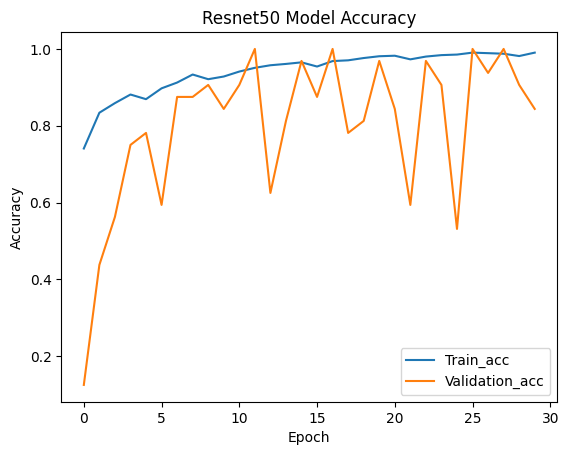

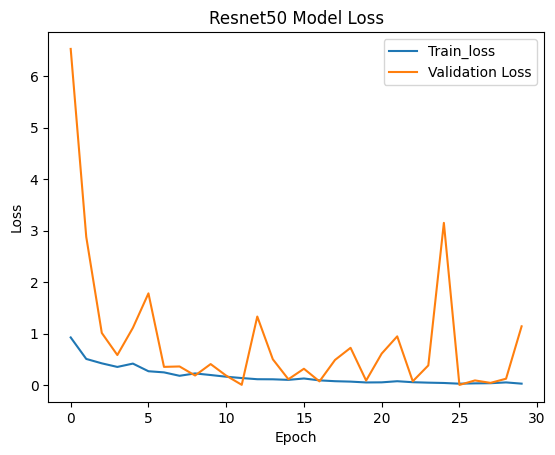

In [20]:
plt.plot(hist.history['accuracy'])
plt.plot(hist.history['val_accuracy'])
plt.title('Resnet50 Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(["Train_acc","Validation_acc"])
plt.show()

plt.plot(hist.history['loss'])
plt.plot(hist.history['val_loss'])
plt.title('Resnet50 Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(["Train_loss","Validation Loss"])
plt.show()

In [21]:
test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(TEST_PATH,
                                                  batch_size=1,
                                                  target_size=SIZE,
                                                  shuffle = False,
                                                  classes=labels,
                                                  class_mode='categorical')


filenames = test_generator.filenames
nb_samples = len(filenames)

loss, acc = model.evaluate(test_generator,steps = (nb_samples), verbose=1)
print('accuracy test: ',acc)
print('loss test: ',loss)

Found 2698 images belonging to 6 classes.
2698/2698 ━━━━━━━━━━━━━━━━━━━━ 23s 8ms/step - accuracy: 0.8006 - loss: 1.2632
accuracy test:  0.8306152820587158
loss test:  1.1303296089172363


In [22]:
predictions = model.predict(test_generator)
files=test_generator.filenames
class_dict=test_generator.class_indices # a dictionary of the form class name: class index
rev_dict={}
for key, value in class_dict.items():
    rev_dict[value]=key

for i, p in enumerate(predictions):
    index=np.argmax(p)
    klass=rev_dict[index]
    prob=p[index]

/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


2698/2698 ━━━━━━━━━━━━━━━━━━━━ 22s 7ms/step


In [23]:
print(len(test_generator[0][0]))
print(test_generator[0][1].shape)

1
(1, 6)


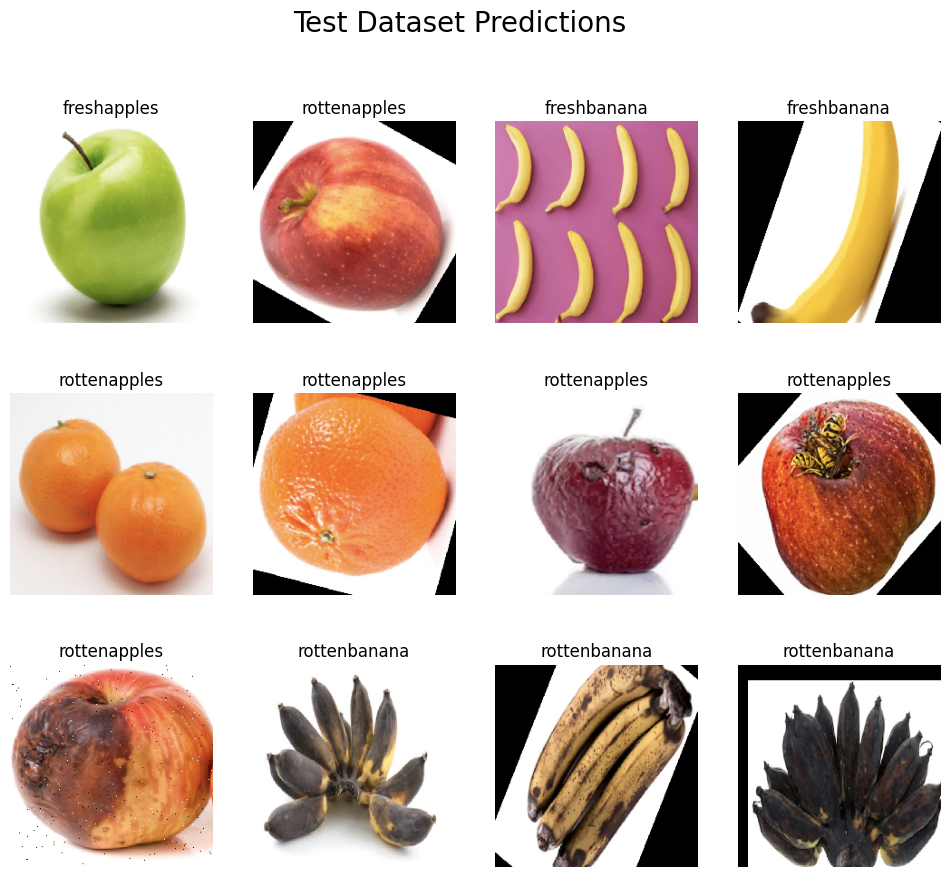

In [25]:
fig, ax = plt.subplots(nrows=3, ncols=4, figsize=(12, 10))
idx = 0

for i in range(3):
    for j in range(4):
        predicted_label = labels[np.argmax(predictions[idx])]
        ax[i, j].set_title(f"{predicted_label}")
        ax[i, j].imshow(test_generator[idx][0].reshape(224,224,3))
        ax[i, j].axis("off")
        idx += 200

# plt.tight_layout()
plt.suptitle("Test Dataset Predictions", fontsize=20)
plt.show()

In [28]:
!apt-get install graphviz -y # Install Graphviz if it's not already installed
!pip install pydot

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
graphviz is already the newest version (2.42.2-6ubuntu0.1).
0 upgraded, 0 newly installed, 0 to remove and 30 not upgraded.


In [30]:
# from tensorflow.keras.utils import plot_model
# tf.keras.utils.plot_model(
# model, to_file='model.png', show_shapes=True, show_dtype=False,
# show_layer_names=True, rankdir='TB', expand_nested=False, dpi=96
# )

"dot" with args ['-Tpng', '/tmp/tmpdmc83ahi/tmpgddh6swp'] returned code: -6

stdout, stderr:
 b''
b"failed at node 10274[1]\ndot: maze.c:313: chkSgraph: Assertion `np->cells[1]' failed.\n"



AssertionError: "dot" with args ['-Tpng', '/tmp/tmpdmc83ahi/tmpgddh6swp'] returned code: -6

In [31]:
!pip install visualkeras

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 997.4/997.4 kB 17.1 MB/s eta 0:00:00


In [32]:
from tensorflow.keras import layers
from collections import defaultdict
# from PIL import ImageFont
# font = ImageFont.truetype("arial.ttf", 12)
color_map = defaultdict(dict) #customize the colours
color_map[layers.Conv2D]['fill'] = '#00f5d4'
color_map[layers.MaxPooling2D]['fill'] = '#8338ec'
color_map[layers.Dropout]['fill'] = '#03045e'
color_map[layers.Dense]['fill'] = '#fb5607'
color_map[layers.Flatten]['fill'] = '#ffbe0b'
# visualkeras.layered_view(model, legend=True,color_map=color_map,scale_xy=2, scale_z=1, max_z=200)

In [34]:
test_steps_per_epoch = int(np.ceil(test_generator.samples / test_generator.batch_size))

In [36]:

predictions = model.predict(test_generator, steps=test_steps_per_epoch)
# Get most likely class
predicted_classes = np.argmax(predictions, axis=1)

2698/2698 ━━━━━━━━━━━━━━━━━━━━ 19s 7ms/step


In [37]:
true_classes = test_generator.classes
class_labels = list(test_generator.class_indices.keys())

In [38]:
from sklearn.metrics import classification_report,confusion_matrix
report = classification_report(true_classes, predicted_classes, target_names=class_labels)
print(report)

               precision    recall  f1-score   support

  freshapples       1.00      0.85      0.92       395
  freshbanana       0.99      0.98      0.99       381
 freshoranges       1.00      0.12      0.22       388
 rottenapples       0.62      0.99      0.76       601
 rottenbanana       0.99      1.00      0.99       530
rottenoranges       0.81      0.89      0.85       403

     accuracy                           0.83      2698
    macro avg       0.90      0.81      0.79      2698
 weighted avg       0.88      0.83      0.80      2698



In [39]:
print('Confusion Matrix')
# print(confusion_matrix(test_generator.classes, predicted_classes))
cm = confusion_matrix(test_generator.classes, predicted_classes)

Confusion Matrix


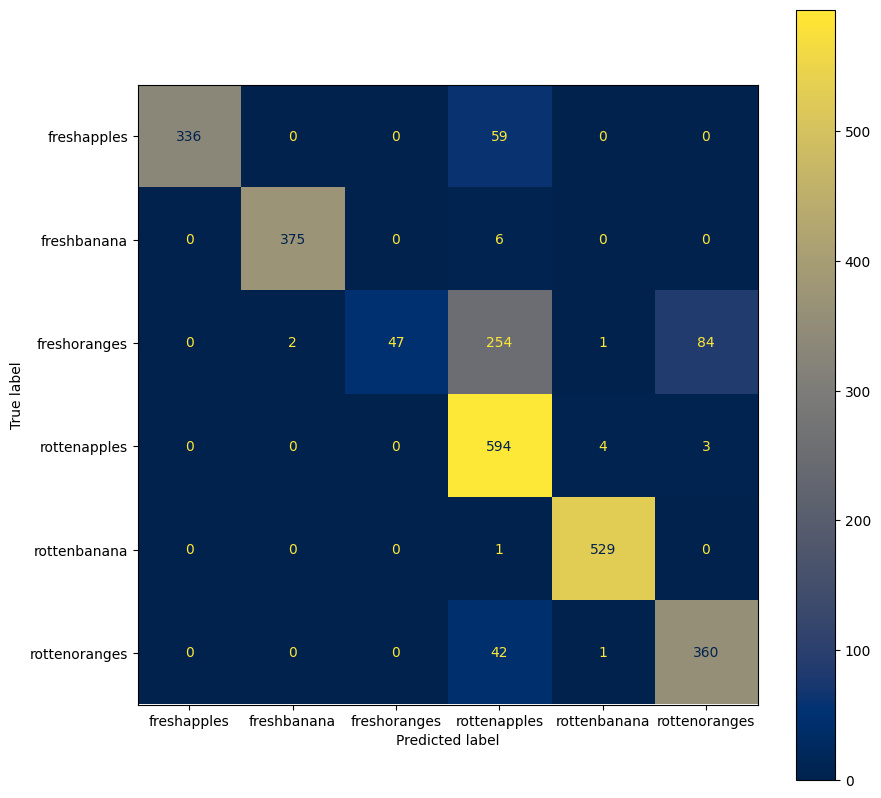

In [40]:
from sklearn.metrics import ConfusionMatrixDisplay
cm = confusion_matrix(test_generator.classes, predicted_classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)
fig, ax = plt.subplots(figsize=(10,10))
disp.plot(ax=ax,cmap="cividis")